In [55]:
from analysis import *

In [56]:
from pathlib import Path

filename="/home/dqian/Projects/bft/DOM-BFT/results_final/n_10k_skip/n6_aligns.out"

all_events = []
dumps = []

with open(filename) as f:
    for line in f:
        if "DUMP" in line: 
            continue
        else:
            all_events.append(parse_line(line))
        
all_events = sorted(all_events, key=lambda x: x['time'])

    

In [57]:
# Find the first repair start after 10 seconds and its corresponding repair end. Get the events for the surrounding 1 seconds

start_time = all_events[0]['time'] + datetime.timedelta(seconds=10)
end_time = start_time + datetime.timedelta(seconds=30)


events = list(filter(lambda x: x['time'] > start_time and x['time'] < end_time, all_events))

for e in events:
    e['t'] = (e['time'] - start_time).total_seconds()

In [58]:
cp_starts = [x for x in events if x["event"] == 'checkpoint_start']
cp_ends = [x for x in events if x["event"] == 'checkpoint_end']
aligns = [x for x in events if x["event"] == 'align']

# Alignment ops

In [63]:
# Find align_start and align events, reset count on repair_start and repair_end
align_starts = [e for e in all_events if e.get("event") == "align_start"]
align_ends = [e for e in all_events if e.get("event") == "align"]
repair_starts = [e for e in all_events if e.get("event") == "repair_start"]
repair_ends = [e for e in all_events if e.get("event") == "repair_end"]

print(f"Total align_start events: {len(align_starts)}")
print(f"Total align events: {len(align_ends)}")
print(f"Total repair_start events: {len(repair_starts)}")
print(f"Total repair_end events: {len(repair_ends)}")

# Create timeline of all events
timeline_events = []

for e in align_starts:
    timeline_events.append({
        'time': e['time'], 
        'type': 'align_start', 
        'replica_id': e.get('replica_id'),
        'seq': e.get('seq')
    })

for e in align_ends:
    timeline_events.append({
        'time': e['time'], 
        'type': 'align_end', 
        'replica_id': e.get('replicaId'),
        'seq': e.get('checkpoint_seq')
    })

for e in repair_starts:
    timeline_events.append({
        'time': e['time'], 
        'type': 'repair_start', 
        'replica_id': None,
        'seq': None
    })

for e in repair_ends:
    timeline_events.append({
        'time': e['time'], 
        'type': 'repair_end', 
        'replica_id': None,
        'seq': None
    })

# Sort by time
timeline_events = sorted(timeline_events, key=lambda x: x['time'])

# Track active replicas (not replica+seq pairs)
active_replicas = set()
max_concurrent = 0
timeline_data = []

for event in timeline_events:
    if event['type'] in ['repair_start', 'repair_end']:
        active_replicas.clear()  # Reset on repair start or end
    elif event['type'] == 'align_start':
        active_replicas.add(event['replica_id'])
    elif event['type'] == 'align_end':
        # Only remove if this replica is in the set
        active_replicas.discard(event['replica_id'])
    
    concurrent_count = len(active_replicas)
    max_concurrent = max(max_concurrent, concurrent_count)
    timeline_data.append({
        'time': event['time'], 
        'count': concurrent_count, 
        'type': event['type'], 
        'replica_id': event['replica_id'],
        'seq': event['seq']
    })

print(f"\nMaximum concurrent alignments: {max_concurrent}")
if max_concurrent > 1:
    print(f"\nTimes when concurrent alignments > 1:")
    for d in timeline_data:
        if d['count'] > 1:
            print(f"  Time: {d['time']}, Count: {d['count']}, Type: {d['type']}, Replica: {d['replica_id']}, Seq: {d['seq']}")

Total align_start events: 124
Total align events: 119
Total repair_start events: 654
Total repair_end events: 654

Maximum concurrent alignments: 2

Times when concurrent alignments > 1:
  Time: 1900-01-01 04:31:25.575367, Count: 2, Type: align_start, Replica: 3, Seq: 3891000


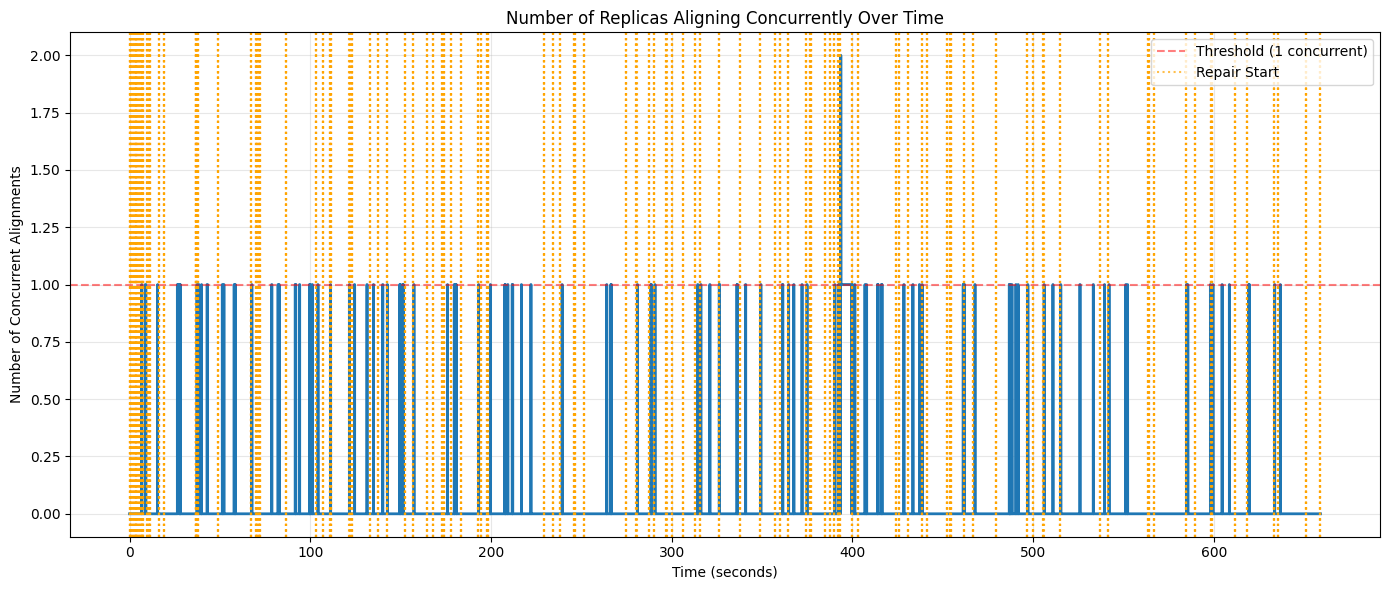

In [65]:
# Plot concurrent alignments over time
import matplotlib.pyplot as plt

if len(timeline_data) > 0:
    start_time = timeline_data[0]['time']
    times = [(d['time'] - start_time).total_seconds() for d in timeline_data]
    counts = [d['count'] for d in timeline_data]
    
    # Get repair_start times
    repair_times = [(d['time'] - start_time).total_seconds() for d in timeline_data if d['type'] == 'repair_start']
    
    plt.figure(figsize=(14, 6))
    plt.step(times, counts, where='post', linewidth=2)
    plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Threshold (1 concurrent)')
    
    # Plot repair starts as vertical lines
    for t in repair_times:
        plt.axvline(x=t, color='orange', linestyle=':', alpha=0.7)
    
    # Add a single label for repair starts in legend
    if repair_times:
        plt.axvline(x=repair_times[0], color='orange', linestyle=':', alpha=0.7, label='Repair Start')
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Number of Concurrent Alignments')
    plt.title('Number of Replicas Aligning Concurrently Over Time')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No timeline data to plot")

Found 1 periods with 3+ concurrent alignments


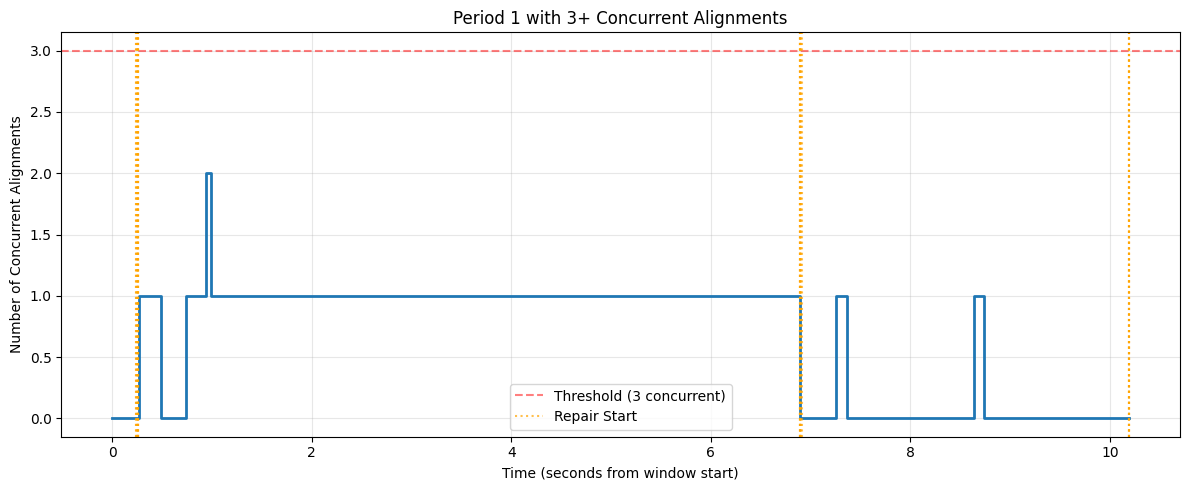


Period 1 - All events in window:
    0.0000s - repair_end           replica=  5 seq=3880313
    0.0001s - repair_end           replica=  1 seq=3880313
    0.0019s - repair_end           replica=?   seq=3880313
    0.0020s - repair_end           replica=  4 seq=3880313
    0.0128s - repair_commit        replica=  3 seq=3880281
    0.0128s - repair_apply         replica=  3 seq=3880281
    0.0129s - repair_commit        replica=  3 seq=3880281
    0.0129s - repair_apply         replica=  3 seq=3880281
    0.0139s - repair_commit        replica=  2 seq=3880272
    0.0139s - repair_apply         replica=  2 seq=3880272
    0.0220s - repair_end           replica=  2 seq=3880313
    0.1331s - repair_end           replica=  3 seq=3880313
    0.2401s - repair_start         replica=  2 seq=3884601
    0.2460s - repair_start         replica=  3 seq=3884537
    0.2619s - repair_start         replica=  4 seq=3884820
    0.2622s - repair_start         replica=?   seq=3884825
    0.2630s - repair_s

In [70]:
# Zoom into periods where 3+ parallel alignments happen
import matplotlib.pyplot as plt

# Find periods where count >= 3
high_periods = []
in_high = False
period_start_idx = None

for i, d in enumerate(timeline_data):
    if d['count'] >= 2 and not in_high:
        period_start_idx = i
        in_high = True
    elif d['count'] < 2 and in_high:
        high_periods.append((period_start_idx, i))
        in_high = False

if in_high:
    high_periods.append((period_start_idx, len(timeline_data) - 1))

print(f"Found {len(high_periods)} periods with 3+ concurrent alignments")

# Plot each period with some margin
for idx, (start_idx, end_idx) in enumerate(high_periods):
    margin = 20
    plot_start = max(0, start_idx - margin)
    plot_end = min(len(timeline_data) - 1, end_idx + margin)
    
    start_time = timeline_data[plot_start]['time']
    plot_times = [(timeline_data[i]['time'] - start_time).total_seconds() for i in range(plot_start, plot_end + 1)]
    plot_counts = [timeline_data[i]['count'] for i in range(plot_start, plot_end + 1)]
    
    # Get repair starts in this window
    repair_times = [(timeline_data[i]['time'] - start_time).total_seconds() 
                    for i in range(plot_start, plot_end + 1) 
                    if timeline_data[i]['type'] == 'repair_start']
    
    plt.figure(figsize=(12, 5))
    plt.step(plot_times, plot_counts, where='post', linewidth=2)
    plt.axhline(y=3, color='r', linestyle='--', alpha=0.5, label='Threshold (3 concurrent)')
    
    # Plot repair starts
    for t in repair_times:
        plt.axvline(x=t, color='orange', linestyle=':', alpha=0.7)
    
    if repair_times:
        plt.axvline(x=repair_times[0], color='orange', linestyle=':', alpha=0.7, label='Repair Start')
    
    plt.xlabel('Time (seconds from window start)')
    plt.ylabel('Number of Concurrent Alignments')
    plt.title(f'Period {idx+1} with 3+ Concurrent Alignments')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print ALL events in this window (not just align events)
    print(f"\nPeriod {idx+1} - All events in window:")
    window_start_time = timeline_data[plot_start]['time']
    window_end_time = timeline_data[plot_end]['time']
    
    window_events = [e for e in all_events if window_start_time <= e['time'] <= window_end_time]
    
    for e in window_events:
        t_offset = (e['time'] - start_time).total_seconds()
        event_type = e.get('event', 'unknown')
        replica_id = e.get('replica_id') or e.get('replicaId', '?')
        seq = e.get('seq') or e.get('checkpoint_seq', '?')

        if event_type.startswith("checkpoint"): continue
        
        print(f"  {t_offset:8.4f}s - {event_type:20s} replica={replica_id:3} seq={seq}")

# Old per-checkpoint plots

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Filter commit events
commit_events = [e for e in events if e["event"] == "commit" and e["client_id"] == 0]

# Extract data
ts = [e["t"] for e in commit_events]               # use 't' instead of 'time'
latencies = [e["latency"] /1000 for e in commit_events]



def commit_color(e):
    if e["path"] == "fast":
        return "c" if e["queued"] == 1 else "g"
    elif e["path"] == "normal":
        return "b"

colors = [commit_color(e) for e in commit_events]


text_y = 10

t_start = cp_starts[-1]["t"]
plt.axvline(x=t_start, color='gray', linestyle='--')
plt.text(t_start - 0.005, text_y, 'Checkpoint Start', color='gray', rotation=90, va='bottom', ha='right')

t_end = cp_ends[-1]["t"]
plt.axvline(x=t_end, color='gray', linestyle='--')
plt.text(t_end - 0.005, text_y, 'Checkpoint End', color='gray', rotation=90, va='bottom', ha='right')

t_align = aligns[-1]["t"]
plt.axvline(x=t_align, color='gray', linestyle='--')
plt.text(t_align - 0.005, text_y, 'Replica Aligned', color='gray', rotation=90, va='bottom', ha='right')

# Cheat here, every 100 ops is diverged, find first commmit that is mod 100

c_div = (x for x in events if x["event"] == "spec_execute" and x["seq"] % 1000 == 0)
print(list(c_div))
t_div = next(c_div)["t"]

plt.axvline(x=t_div, color='gray', linestyle='--')
plt.text(t_div - 0.005, text_y, 'Replica Diverged', color='gray', rotation=90, va='bottom', ha='right')


plt.ylim(bottom=0, top=200)

# Create the scatter plot
plt.scatter(ts, latencies, c=colors, alpha=0.5)

# Labels and title
plt.xlabel("Time (t)")
plt.ylabel("Latency (ms)")
plt.title("Latency of Commit Events Over Time")

plt.tight_layout()
plt.show()


In [ ]:
cs = [x for x in commit_events if x["client_id"] == 0]

start_times = [x["time"].timestamp() - x["latency"] / 10**6 for x in cs]
min_t = min(start_times)

starts = [t - min_t for t in start_times] 

data = list(zip(starts, cs))
data = sorted(data, key=lambda t: t[0])

latencies = [(t, x["latency"] / 1000) for t, x in data]


text_y = 10

plt.axvline(x=t_align, color='gray', linestyle='--')
plt.text(t_align + 0.01, text_y, 'Replica Aligned', color='gray', rotation=90, va='bottom', ha='left')

plt.axvline(x=t_div, color='gray', linestyle='--')
plt.text(t_div + 0.01, text_y, 'Replica Diverged', color='gray', rotation=90, va='bottom', ha='left')



plt.axvline(x=t_start, color='gray', linestyle='--')
plt.text(t_start + 0.01, text_y, 'Checkpoint Start', color='gray', rotation=90, va='bottom', ha='left')

plt.axvline(x=t_end, color='gray', linestyle='--')
plt.text(t_end + 0.01, text_y, 'Checkpoint End', color='gray', rotation=90, va='bottom', ha='left')


plt.xlabel("Submission Time (s)")
plt.ylabel("Latency (ms)")
plt.title("Latency of Commit Events Over Time")

times, latencies = zip(*latencies)
plt.ylim(bottom=0, top=200)
plt.xlim(left=0, right=1)

plt.plot(times, latencies)
